In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
df = pd.read_csv("/content/Crash_Reporting_-_Incidents_Data_20260515.csv")
df['ACRS Report Type']

/tmp/ipykernel_3955/3337332766.py:1: DtypeWarning: Columns (1,9,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Crash_Reporting_-_Incidents_Data_20260515.csv")


,ACRS Report Type
0,Property Damage Crash
1,Property Damage Crash
2,Property Damage Crash
3,Property Damage Crash
4,Injury Crash
...,...
121898,Property Damage Crash
121899,Property Damage Crash
121900,Injury Crash
121901,Property Damage Crash


In [6]:
print(df.columns.tolist())

['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Hit/Run', 'Route Type', 'Lane Direction', 'Lane Type', 'Number of Lanes', 'Direction', 'Distance', 'Distance Unit', 'Road Grade', 'Road Name', 'Cross-Street Name', 'Off-Road Description', 'Municipality', 'Related Non-Motorist', 'At Fault', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'First Harmful Event', 'Second Harmful Event', 'Junction', 'Intersection Type', 'Road Alignment', 'Road Condition', 'Road Division', 'Latitude', 'Longitude', 'Location']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [8]:
df['Is_Fatal'] = df['ACRS Report Type'].apply(lambda x: 1 if 'Fatal' in str(x) else 0)

# --- STEP 2: SELECT PREDICTORS AND ONE-HOT ENCODE ---
# Selected a subset of relevant behavioral and environmental predictors from your list
predictors = [
    'Weather',
    'Surface Condition',
    'Light',
    'Traffic Control',
    'Driver Substance Abuse',
    'Road Grade',
    'Collision Type'
]

In [9]:
df_model = df.dropna(subset=['Is_Fatal'] + predictors).copy()

# Convert categorical variables into binary dummy features (0 or 1)
X = pd.get_dummies(df_model[predictors], drop_first=True)
y = df_model['Is_Fatal']

# --- STEP 3: TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# --- STEP 5: PREDICT AND EVALUATE ---
y_pred = model.predict(X_test)

# Print Precision, Recall, and F1-score metrics
print("--- Evaluation Metrics (Precision-Recall) ---")
print(classification_report(y_test, y_pred))

--- Evaluation Metrics (Precision-Recall) ---
              precision    recall  f1-score   support

           0       1.00      0.81      0.90     23409
           1       0.01      0.69      0.03        89

    accuracy                           0.81     23498
   macro avg       0.51      0.75      0.46     23498
weighted avg       0.99      0.81      0.89     23498



--- Confusion Matrix ---


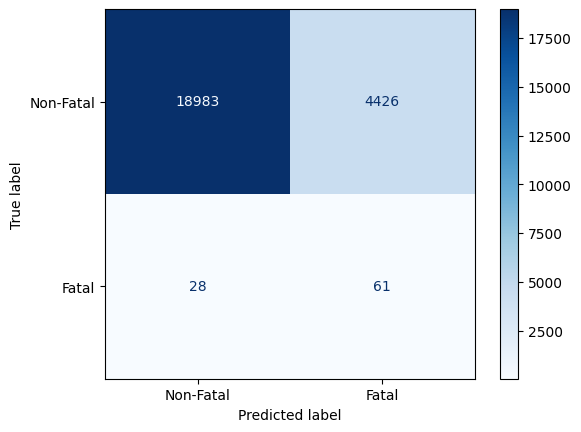

In [11]:
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fatal', 'Fatal'])
disp.plot(cmap='Blues')